### Demand-Side Management MPC (DSMPC) HALL AND ERDIN

Copyright (&copy;) 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

#### Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import colormaps
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC

In [3]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

#### Approximate Infinite-Horizon Overtaking-Optimal Trajectory

In [4]:
# Load parameters and create system with a long horizon
zeta_max = 40 * np.ones([96,10]); zeta_max[23::24,:] = 1
params_inf = DSMPCParams(N=200, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = EMPC(sys_inf, params_inf.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg = ctrl_inf.solve(t=0)
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_inf = sol_x.T
u_inf = sol_u.T

#### Simulate System Without Terminal Ingredients

##### Solve DSMPC for Varying Initial States

In [5]:
# Load parameters and create system
params = DSMPCParams(T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
sys = LinearSystem(params.sys)

# Initialize controller
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
x = np.full((num_traj, num_steps+1, sys.n), np.nan)
u = np.full((num_traj, num_steps,   sys.m), np.nan)
x_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
u_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories')):
    # Set initial state
    x[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl.solve(t=t, x_0=x[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            x_ol[i,:] = sol_x.T
            u_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Some debug information
        # tmp = np.abs(sol_x[:,1] - sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,)))
        # print('At time {0} Dynamics is {1} with diff: {2}'.format(t,np.all(tmp < 1E-5), np.max(tmp)))
        sleep(0.01)

Trajectories:   0%|          | 0/5 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

##### Solve DSMPC for Varying Horizons

In [6]:
# Setup simulation
num_steps = 48
x_0 = np.zeros((sys.n,))
horizon = [6, 9, 12, 18, 24]
num_horizon = len(horizon)

# Allocate state and input trajectories
x2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
u2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
x2_ol = np.full((num_horizon, max(horizon)+1, sys.n), np.nan)
u2_ol = np.full((num_horizon, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons')):
    # Load parameters and create system
    params2 = DSMPCParams(N=N, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = EMPC(sys2, params2.ctrl)

    # Set initial state
    x2[i,0,:] = x_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl2.solve(t=t, x_0=x2[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            x2_ol[i,:N+1,:] = sol_x.T
            u2_ol[i,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        u2[i,t,:]   = sol_u[:,0]
        x2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

Horizons:   0%|          | 0/5 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

#### Simulate System With Terminal Ingredients

##### Compute Periodic Reference Trajectory

In [7]:
# Load parameters and create system with a long horizon
zeta_max = 40 * np.ones([96,10]); zeta_max[23::24,:] = 1
params_inf = DSMPCParams(N=96, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = EMPC(sys_inf, params_inf.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg = ctrl_inf.solve(t=0, periodic=True)
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_p = sol_x.T
u_p = sol_u.T

##### Solve DSMPC for Varying Initial States

In [8]:
# Initialize controller
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
xt = np.full((num_traj, num_steps+1, sys.n), np.nan)
ut = np.full((num_traj, num_steps,   sys.m), np.nan)
xt_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
ut_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories')):
    # Set initial state
    xt[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl.solve(t=t, x_0=xt[i,t,:], x_T=x_p[t+24,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt_ol[i,:] = sol_x.T
            ut_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        ut[i,t,:]   = sol_u[:,0]
        xt[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

Trajectories:   0%|          | 0/5 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

c:\Users\alexe\miniconda3\envs\time-varying-rhgs\lib\site-packages\cvxpy\problems\problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
C:\Users\alexe\AppData\Local\Temp\ipykernel_6164\4050486700.py:25: UserWarning: Solver did not achieve an optimal solution. Status: infeasible_inaccurate
  warnings.warn(error_msg)


     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

C:\Users\alexe\AppData\Local\Temp\ipykernel_6164\4050486700.py:25: UserWarning: Solver did not achieve an optimal solution. Status: infeasible
  warnings.warn(error_msg)


##### Solve DSMPC for Varying Horizons

In [9]:
# Setup simulation
num_steps = 48
x_0 = np.zeros((sys.n,))
horizon = [6, 9, 12, 18, 24]
num_horizon = len(horizon)

# Allocate state and input trajectories
xt2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
ut2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
xt2_ol = np.full((num_horizon, max(horizon)+1, sys.n), np.nan)
ut2_ol = np.full((num_horizon, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons')):
    # Load parameters and create system
    params2 = DSMPCParams(N=N, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = EMPC(sys2, params2.ctrl)

    # Set initial state
    xt2[i,0,:] = x_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl2.solve(t=t, x_0=xt2[i,t,:], x_T=x_p[t+N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt2_ol[i,:N+1,:] = sol_x.T
            ut2_ol[i,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        ut2[i,t,:]   = sol_u[:,0]
        xt2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

Horizons:   0%|          | 0/5 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

#### Plot Results

##### Sophie's Plot

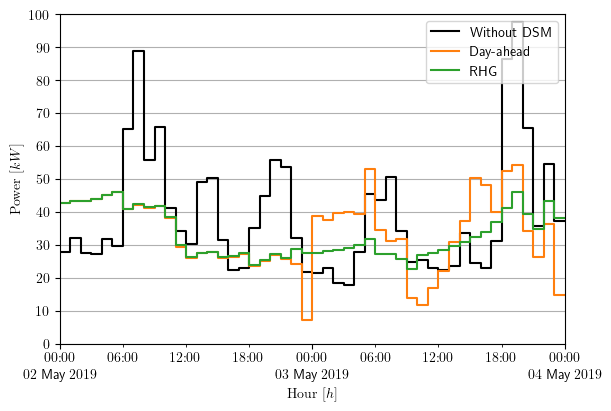

In [10]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute passive load without DSM
n_tile = np.ceil(num_steps/sys.T).astype(int)
no_dsm = np.tile(params.ctrl.consumption.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps]
no_dsm = np.hstack([no_dsm, no_dsm[-1]])

# Compute aggregate load
agg_load    = [u[i,:].sum(axis=1) + np.tile(-params.ctrl.solar.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps] for i in range(num_traj)]
agg_load_ol = [np.tile(u_ol[i,:].sum(axis=1), 2) + np.tile(-params.ctrl.solar.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps] for i in range(num_traj)]
agg_load    = [np.hstack([agg_load[t],    agg_load[t][-1]]) for t in range(num_traj)]
agg_load_ol = [np.hstack([agg_load_ol[t], agg_load_ol[t][-1]]) for t in range(num_traj)]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot passive load
axs.plot(dates, no_dsm, label='Without DSM', color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories
axs.plot(dates, agg_load_ol[0], label='Day-ahead', color='tab:orange', linestyle='-', drawstyle='steps-post')
axs.plot(dates, agg_load[0], label='RHG', color='tab:green', linestyle='-', drawstyle='steps-post')

# Add labels
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')
axs.set_ylabel(r'\rmfamily{Power} $[kW]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
axs.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
axs.tick_params(axis="x", which="minor", pad=axs.xaxis.get_tick_padding())

# Set limits
axs.set_xlim([dates[0], dates[-1]])
axs.set_ylim([0, 100])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)

# Plot legend
axs.legend(loc='upper right')

# Export figure
fig.savefig("figures/figure_hall.pdf", bbox_inches='tight', pad_inches=0.1)

##### Convergence to the Overtaking-Optimal Trajectory

To observe asymptotic convergence and the Turnpike effect, we plot accumulated states and inputs for our multidimensional system. These cumulative plots should be interpreted with caution, as individual trajectories may offset one another, potentially masking the presence (or absence) of asymptotic convergence and/or the Turnpike effect. Nonetheless, they offer a useful preliminary assessment of the system's behavior. The accumulated states are defined by
\begin{equation}
    \bar{\zeta}_t := \sum_{v \in \mathcal{A}} \zeta_t^v, \qquad \bar{q}_t := \sum_{v \in \mathcal{A}} q_t^v
\end{equation}
with $\bar{x}_t := (\bar{\zeta}_t, \bar{q}_t)$ being the accumulated state vector. The accumulated inputs $\bar{u}_t$ are defined analogously.

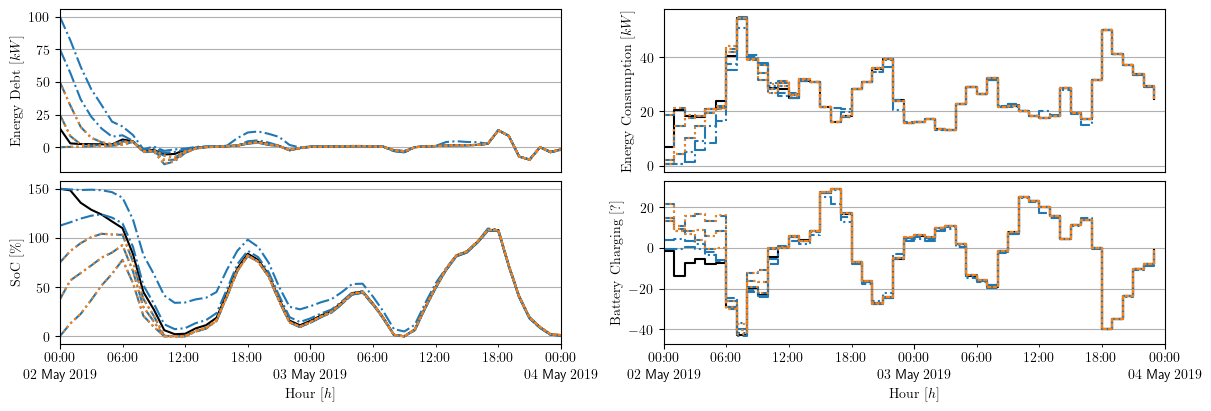

In [11]:
# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(params.ctrl.N+1)]

# Compute accumulated states
x_acc  = np.zeros((num_traj, num_steps+1, 2))
u_acc  = np.zeros((num_traj, num_steps,   2))
xt_acc = np.zeros((num_traj, num_steps+1, 2))
ut_acc = np.zeros((num_traj, num_steps,   2))
x_acc_ol = np.zeros((num_traj, params.ctrl.N+1, 2))
u_acc_ol = np.zeros((num_traj, params.ctrl.N,   2))
for i in range(num_traj):
    x_acc[i,:,:]  = np.vstack([x[i,:,0::2].sum(axis=1), x[i,:,1::2].sum(axis=1)]).T
    u_acc[i,:,:]  = np.vstack([u[i,:,0::2].sum(axis=1), u[i,:,1::2].sum(axis=1)]).T
    xt_acc[i,:,:] = np.vstack([xt[i,:,0::2].sum(axis=1), xt[i,:,1::2].sum(axis=1)]).T
    ut_acc[i,:,:] = np.vstack([ut[i,:,0::2].sum(axis=1), ut[i,:,1::2].sum(axis=1)]).T
    x_acc_ol[i,:,:] = np.vstack([x_ol[i,:,0::2].sum(axis=1), x_ol[i,:,1::2].sum(axis=1)]).T
    u_acc_ol[i,:,:] = np.vstack([u_ol[i,:,0::2].sum(axis=1), u_ol[i,:,1::2].sum(axis=1)]).T
x_acc_inf = np.vstack([x_inf[:,0::2].sum(axis=1), x_inf[:,1::2].sum(axis=1)]).T
u_acc_inf = np.vstack([u_inf[:,0::2].sum(axis=1), u_inf[:,1::2].sum(axis=1)]).T
x_acc_p = np.vstack([x_p[:,0::2].sum(axis=1), x_p[:,1::2].sum(axis=1)]).T
u_acc_p = np.vstack([u_p[:,0::2].sum(axis=1), u_p[:,1::2].sum(axis=1)]).T

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot approximate overtaking-optimal trajectories
axs[0][0].plot(dates, x_acc_inf[:num_steps+1,0], color='black', linestyle='-')
axs[1][0].plot(dates, x_acc_inf[:num_steps+1,1], color='black', linestyle='-')
axs[0][1].plot(dates[:-1], u_acc_inf[:num_steps,0], color='black', linestyle='-', drawstyle='steps-post')
axs[1][1].plot(dates[:-1], u_acc_inf[:num_steps,1], color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    axs[0][0].plot(dates, x_acc[i,:,0], color='tab:blue', linestyle='-.')
    axs[1][0].plot(dates, x_acc[i,:,1], color='tab:blue', linestyle='-.')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color='tab:blue', linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color='tab:blue', linestyle='-.', drawstyle='steps-post')

# Plot trajectories with terminal constraints
for i in range(num_traj):
    axs[0][0].plot(dates, xt_acc[i,:,0], color='tab:orange', linestyle=':')
    axs[1][0].plot(dates, xt_acc[i,:,1], color='tab:orange', linestyle=':')
    axs[0][1].plot(dates[:-1], ut_acc[i,:,0], color='tab:orange', linestyle=':', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], ut_acc[i,:,1], color='tab:orange', linestyle=':', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Export figure
fig.savefig("figures/figure_asymptotic_convergence.pdf", bbox_inches='tight', pad_inches=0.1)

##### Compare Cost

In [12]:
# Compute cost with and without terminal constraints
data = []
for i in range(num_traj):
    cost, costt = 0, 0
    for k in range(num_steps):
        cost  += params.ctrl.stage_cost(x[i, k],  u[i, k],  t=k)[0]
        costt += params.ctrl.stage_cost(xt[i, k], ut[i, k], t=k)[0]
    
    # Append the computed costs
    data.append([cost, costt])

# Create a pandas DataFrame
columns = pd.MultiIndex.from_tuples([('Cost', 'Without'), ('Cost', 'With')])
cost_df = pd.DataFrame(data, columns=columns, index=pd.Index(range(num_traj), name="Trajectory"))
cost_df

Cost              
                 Without          With
Trajectory                            
0           30299.235613  30327.490990
1           27918.862319  27945.802992
2           27541.958577  27568.024392
3           30191.333523           NaN
4           38628.306038           NaN

##### Turnpike Plots

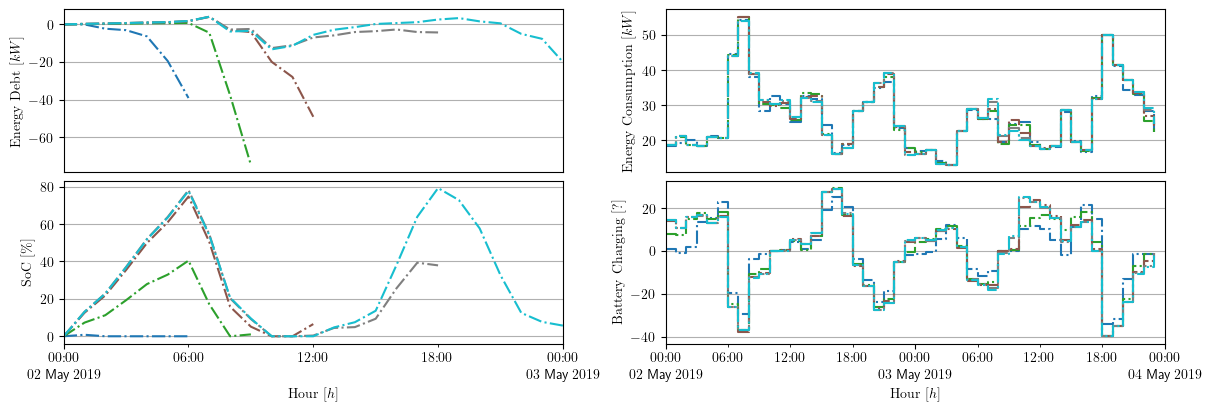

In [13]:
# Create time vector
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(max(horizon)+1)]

# Compute accumulated states
x_acc = np.zeros((num_horizon, num_steps+1, 2))
u_acc = np.zeros((num_horizon, num_steps,   2))
x_acc_ol = np.zeros((num_horizon, max(horizon)+1, 2))
u_acc_ol = np.zeros((num_horizon, max(horizon),   2))
for i, _ in enumerate(horizon):
    x_acc[i,:,:] = np.vstack([x2[i,:,0::2].sum(axis=1), x2[i,:,1::2].sum(axis=1)]).T
    u_acc[i,:,:] = np.vstack([u2[i,:,0::2].sum(axis=1), u2[i,:,1::2].sum(axis=1)]).T
    x_acc_ol[i,:,:] = np.vstack([x2_ol[i,:,0::2].sum(axis=1), x2_ol[i,:,1::2].sum(axis=1)]).T
    u_acc_ol[i,:,:] = np.vstack([u2_ol[i,:,0::2].sum(axis=1), u2_ol[i,:,1::2].sum(axis=1)]).T

# Create colormap
colors = colormaps['tab10'].resampled(num_horizon)

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories
for i, _ in enumerate(horizon):
    axs[0][0].plot(dates_ol, x_acc_ol[i,:,0], color=colors(i), linestyle='-.')
    axs[1][0].plot(dates_ol, x_acc_ol[i,:,1], color=colors(i), linestyle='-.')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color=colors(i), linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color=colors(i), linestyle='-.', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M \\ %d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    if i % 2 != 0:
        ax.set_xlim([dates[0], dates[-1]])
    else:
        ax.set_xlim([dates[0], dates_ol[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Export figure
fig.savefig("figures/figure_turnpike1.pdf", bbox_inches='tight', pad_inches=0.1)

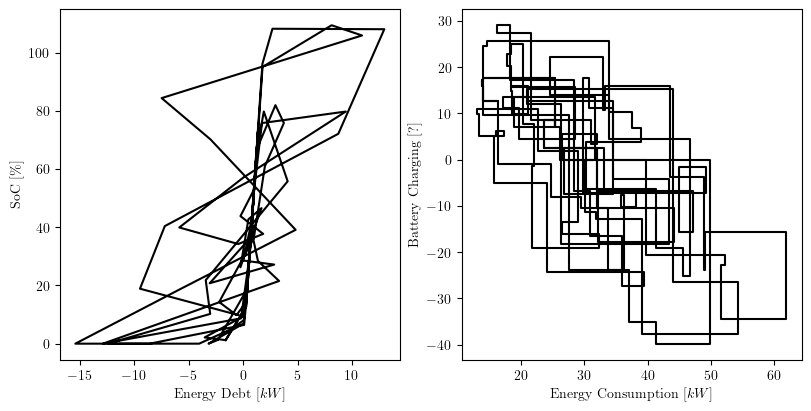

In [14]:
# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout='constrained')

# Plot trajectories
axs[0].plot(x_acc_inf[48:-48,0], x_acc_inf[48:-48,1], color='black', linestyle='-')
axs[1].plot(u_acc_inf[48:-48,0], u_acc_inf[48:-48,1], color='black', linestyle='-', drawstyle='steps-post')
# for i, _ in enumerate(horizon):
#     axs[0].plot(x_acc_ol[i,:,0], x_acc_ol[i,:,1], color='tab:blue', linestyle='-.')
#     axs[1].plot(u_acc[i,:,0], u_acc[i,:,1], color='tab:blue', linestyle='-.', drawstyle='steps-post')

# Add labels
axs[0].set_xlabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[1].set_xlabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$');

# Export figure
fig.savefig("figures/figure_turnpike2.pdf", bbox_inches='tight', pad_inches=0.1)